# 2D Grid-Based A* Path Planning

## Objective

The objective is to implement a standard 2D grid-based A* path planner. The user can define:

- Grid size
- Start position
- Goal position
- Number and locations of obstacles

The planner then searches for a collision-free path from the start to the goal.

The grid is **8-connected**, meaning that from any cell the planner can move to its eight neighbouring cells: up, down, left, right, and the four diagonal directions.

---

## A* Algorithm

A* selects which grid cell to explore using the cost function

\[
F(n) = G(n) + H(n)
\]

where:

- \(G(n)\) is the actual cost of travelling from the start to node \(n\).
- \(H(n)\) is the estimated cost from node \(n\) to the goal.
- \(F(n)\) is the estimated total cost of a path passing through node \(n\).

In this implementation, the heuristic \(H\) is the Euclidean distance between the current node and the goal:

\[
H(n) =
\sqrt{(x_n-x_g)^2+(y_n-y_g)^2}
\]

For movement between neighbouring cells:

- Horizontal/vertical movement has a cost of \(1\).
- Diagonal movement has a cost of \(\sqrt{2}\).

Thus, the planner favours paths with lower total movement cost while also considering the estimated distance remaining to the goal.

---

## Neighbour Selection

For every currently explored cell, the algorithm checks its up to eight neighbouring cells.

A neighbour is rejected if:

1. It lies outside the grid.
2. It is occupied by an obstacle.
3. It would result in diagonal movement through the corner of an obstacle.

Valid neighbours are assigned their corresponding movement cost and added to the set of candidate nodes.

---

## Open Set and Explored Nodes

The **open set** contains nodes that have been discovered but have not yet been fully explored.

The algorithm repeatedly selects the node with the lowest \(F\)-cost from the open set.

That node becomes the current node, and its neighbours are then examined.

The process continues until:

- The goal is reached, or
- There are no more nodes available to explore, meaning that no path exists.

The nodes selected for exploration are stored so that the search process can be visualized.

---

## Path Reconstruction

During the search, the algorithm stores the predecessor of each node in the `came_from` dictionary.

For example:

\[
A \rightarrow B \rightarrow C \rightarrow Goal
\]

is stored through predecessor relationships.

Once the goal is reached, these relationships are followed backwards from the goal to the start. The resulting sequence is then reversed to obtain the final path from start to goal.

Therefore, the **explored nodes and the final path are different**:

- **Explored nodes:** all nodes expanded during the A* search.
- **Final path:** the sequence of nodes selected after reconstructing the best-known route from the goal back to the start.

---

## Visualization

The final plot shows:

- Obstacles in the grid
- Start position
- Goal position
- Explored nodes
- Final A* path

The explored nodes illustrate the search performed by the planner, while the final path represents the route returned by A*.

---

## Important Limitation

This implementation is a **normal 2D grid-based A*** planner.

The state of a node is represented only by its position:

\[
(x,y)
\]

It does not include the vehicle's orientation \(\theta\), steering angle, or turning radius.

Therefore, the resulting path is only guaranteed to be a **collision-free grid path**. It is not necessarily physically executable by the car-like buggy.

In [16]:
import heapq
import math
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. USER INPUT
# ============================================================

# Grid size
ROWS = int(input("Enter number of rows: "))
COLS = int(input("Enter number of columns: "))

# Start position
print("\nEnter start position:")
start_row = int(input("Start row: "))
start_col = int(input("Start column: "))
start = (start_row, start_col)

# Goal position
print("\nEnter goal position:")
goal_row = int(input("Goal row: "))
goal_col = int(input("Goal column: "))
goal = (goal_row, goal_col)

# Number of obstacles
num_obstacles = int(input("\nEnter number of obstacles: "))

obstacles = []

print("\nEnter obstacle positions:")

for i in range(num_obstacles):

    row = int(input(f"Obstacle {i+1} row: "))
    col = int(input(f"Obstacle {i+1} column: "))

    obstacles.append((row, col))


# ============================================================
# 2. CREATE GRID
# ============================================================

# 0 = free cell
# 1 = obstacle

grid = np.zeros((ROWS, COLS), dtype=int)


# ============================================================
# 3. VALIDATE OBSTACLES
# ============================================================

for obstacle in obstacles:

    row, col = obstacle

    if row < 0 or row >= ROWS or col < 0 or col >= COLS:
        raise ValueError(
            f"Obstacle {obstacle} is outside the grid."
        )

    grid[row, col] = 1


# ============================================================
# 4. VALIDATE START AND GOAL
# ============================================================

if not (0 <= start[0] < ROWS and
        0 <= start[1] < COLS):

    raise ValueError("Start position is outside the grid.")


if not (0 <= goal[0] < ROWS and
        0 <= goal[1] < COLS):

    raise ValueError("Goal position is outside the grid.")


if grid[start] == 1:
    raise ValueError("Start position is inside an obstacle.")


if grid[goal] == 1:
    raise ValueError("Goal position is inside an obstacle.")


# ============================================================
# 5. HEURISTIC
# ============================================================

def heuristic(a, b):

    return math.sqrt(
        (a[0] - b[0])**2 +
        (a[1] - b[1])**2
    )


# ============================================================
# 6. GET VALID NEIGHBOURS
# ============================================================

def get_neighbors(node, grid):

    row, col = node

    # 8-connected movement
    directions = [
        (-1, 0),    # Up
        (1, 0),     # Down
        (0, -1),    # Left
        (0, 1),     # Right
        (-1, -1),   # Upper-left
        (-1, 1),    # Upper-right
        (1, -1),    # Lower-left
        (1, 1)      # Lower-right
    ]

    neighbors = []

    rows, cols = grid.shape

    for dr, dc in directions:

        nr = row + dr
        nc = col + dc

        # Check grid boundaries
        if nr < 0 or nr >= rows or nc < 0 or nc >= cols:
            continue

        # Check obstacle
        if grid[nr, nc] == 1:
            continue

        # Prevent diagonal corner cutting
        if dr != 0 and dc != 0:

            if grid[row + dr, col] == 1:
                continue

            if grid[row, col + dc] == 1:
                continue

        # Movement cost
        if dr != 0 and dc != 0:
            cost = math.sqrt(2)
        else:
            cost = 1

        neighbors.append(((nr, nc), cost))

    return neighbors


# ============================================================
# 7. RECONSTRUCT PATH
# ============================================================

def reconstruct_path(came_from, current):

    path = [current]

    while current in came_from:

        current = came_from[current]

        path.append(current)

    # Reverse Goal → Start into Start → Goal
    path.reverse()

    return path


# ============================================================
# 8. A* ALGORITHM
# ============================================================

def astar(grid, start, goal):

    # Priority queue
    open_set = []

    counter = 0

    # Initial F value
    initial_f = heuristic(start, goal)

    heapq.heappush(
        open_set,
        (initial_f, counter, start)
    )

    # Cost from Start to each node
    g_score = {
        start: 0
    }

    # Parent of each node
    came_from = {}

    # Nodes explored
    explored_nodes = []

    # Already explored nodes
    closed_set = set()

    # --------------------------------------------------------
    # Main loop
    # --------------------------------------------------------

    while open_set:

        # Select node with smallest F
        _, _, current = heapq.heappop(open_set)

        # Skip if already explored
        if current in closed_set:
            continue

        # Mark as explored
        closed_set.add(current)
        explored_nodes.append(current)

        # ----------------------------------------------------
        # Goal reached
        # ----------------------------------------------------

        if current == goal:

            path = reconstruct_path(
                came_from,
                current
            )

            return path, explored_nodes, g_score

        # ----------------------------------------------------
        # Explore neighbours
        # ----------------------------------------------------

        for neighbor, movement_cost in get_neighbors(
            current,
            grid
        ):

            if neighbor in closed_set:
                continue

            # Calculate new G
            tentative_g = (
                g_score[current]
                + movement_cost
            )

            # Check if this is a better route
            if (
                neighbor not in g_score
                or tentative_g < g_score[neighbor]
            ):

                # Remember where we came from
                came_from[neighbor] = current

                # Update G
                g_score[neighbor] = tentative_g

                # F = G + H
                f_score = (
                    tentative_g
                    + heuristic(neighbor, goal)
                )

                counter += 1

                # Add to priority queue
                heapq.heappush(
                    open_set,
                    (
                        f_score,
                        counter,
                        neighbor
                    )
                )

    # No path found
    return None, explored_nodes, g_score


# ============================================================
# 9. RUN A*
# ============================================================

path, explored_nodes, g_score = astar(
    grid,
    start,
    goal
)


# ============================================================
# 10. RESULTS
# ============================================================

if path is None:

    print("\nNo path found.")

else:

    # Calculate path length
    path_length = 0

    for i in range(1, len(path)):

        r1, c1 = path[i - 1]
        r2, c2 = path[i]

        path_length += math.sqrt(
            (r2 - r1)**2 +
            (c2 - c1)**2
        )

    print("\n==============================")
    print("        A* RESULTS")
    print("==============================")

    print("Grid size:",
          ROWS, "x", COLS)

    print("Start:",
          start)

    print("Goal:",
          goal)

    print("Number of obstacles:",
          len(obstacles))

    print("Explored nodes:",
          len(explored_nodes))

    print("Path cells:",
          len(path))

    print("Path length:",
          round(path_length, 2),
          "grid units")

    print("\nFinal path:")
    print(path)


# ============================================================
# 11. VISUALIZATION
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 7)
)

# Draw grid
ax.imshow(
    grid,
    cmap="Greys",
    origin="upper"
)


# ------------------------------------------------------------
# Explored nodes
# ------------------------------------------------------------

if explored_nodes:

    explored_rows = [
        node[0]
        for node in explored_nodes
    ]

    explored_cols = [
        node[1]
        for node in explored_nodes
    ]

    ax.scatter(
        explored_cols,
        explored_rows,
        s=15,
        label="Explored nodes"
    )


# ------------------------------------------------------------
# Final path
# ------------------------------------------------------------

if path:

    path_rows = [
        node[0]
        for node in path
    ]

    path_cols = [
        node[1]
        for node in path
    ]

    ax.plot(
        path_cols,
        path_rows,
        linewidth=3,
        label="A* path"
    )


# ------------------------------------------------------------
# Start
# ------------------------------------------------------------

ax.scatter(
    start[1],
    start[0],
    s=120,
    marker="o",
    label="Start"
)


# ------------------------------------------------------------
# Goal
# ------------------------------------------------------------

ax.scatter(
    goal[1],
    goal[0],
    s=120,
    marker="X",
    label="Goal"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_title(
    "2D Grid-Based A* Path Planning"
)

ax.set_xlabel("Grid column")
ax.set_ylabel("Grid row")

ax.set_xticks(
    np.arange(COLS)
)

ax.set_yticks(
    np.arange(ROWS)
)

ax.grid(
    True,
    linewidth=0.5,
    alpha=0.3
)

ax.legend()

plt.show()

Enter number of rows:  1
Enter number of columns:  1



Enter start position:


Start row:  1
Start column:  1



Enter goal position:


Goal row:  1
Goal column:  1

Enter number of obstacles:  1



Enter obstacle positions:


Obstacle 1 row:  1
Obstacle 1 column:  1


<class 'ValueError'>: Obstacle (1, 1) is outside the grid.

## Q1(e) — Testing A* in a Road-Like Environment

A road-like environment was created using a horizontal lane connected to a vertical lane through a **90° bend**. All cells outside the road are treated as blocked, restricting the planner to the drivable region.

Four static obstacles were added to represent parked vehicles or road blockages. The start and goal positions were placed on different sections of the road.

The 8-connected A* planner was then used to find a collision-free path from the start to the goal. The visualization shows the **explored nodes**, **static obstacles**, **off-road regions**, **start and goal**, and the resulting **A* path**.

This test demonstrates that conventional grid-based A* can find a route through a road-like environment with obstacles and a bend. However, the planner considers only the vehicle's position \((x,y)\) and does not account for its heading or minimum turning radius. Therefore, the resulting path may contain turns that the actual buggy cannot execute.

Explored nodes: 78, path nodes: 27, path length: 28.07


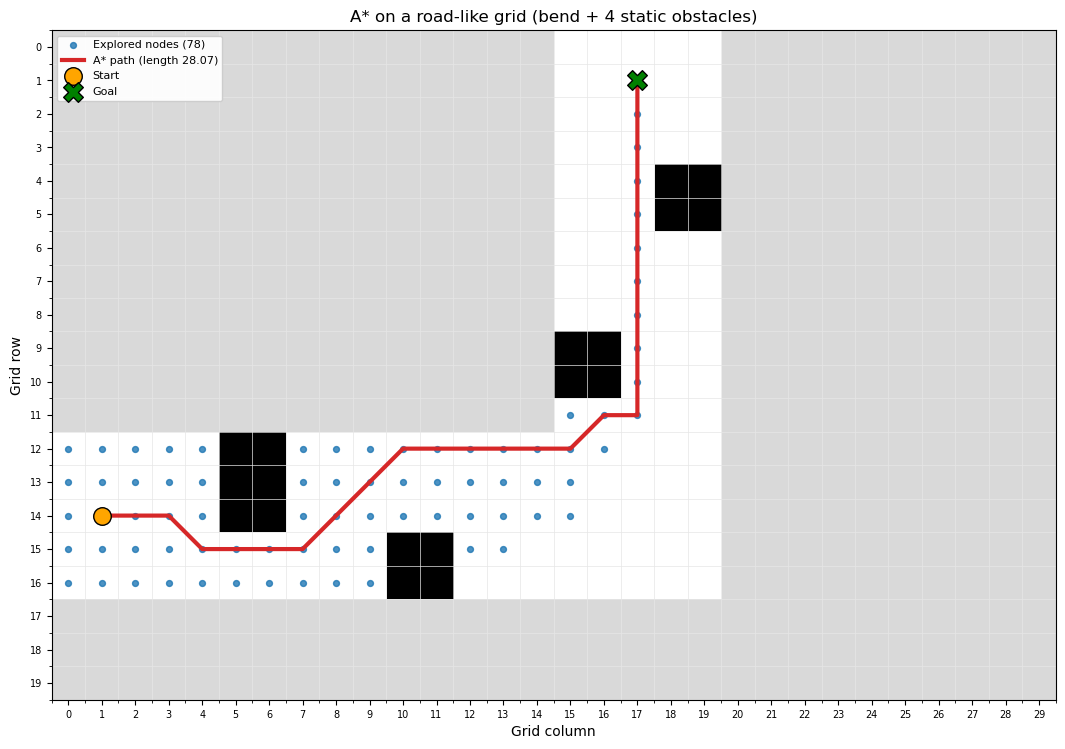

In [15]:
# ---- e) Road-like environment: one 90° bend + 4 static obstacles ----
rows, cols = 20, 30

# Road = horizontal lane + vertical lane joined at a bend
road = set()
for r in range(12, 17):            # horizontal lane: rows 12-16
    for c in range(0, 20):         #                  cols 0-19
        road.add((r, c))
for r in range(0, 17):             # vertical lane:   rows 0-16
    for c in range(15, 20):        #                  cols 15-19
        road.add((r, c))

# Everything that is not road is blocked (drawn grey)
offroad = {(r, c) for r in range(rows) for c in range(cols)} - road

planner = AStarPlanner(rows, cols, obstacles=offroad,
                       allow_diagonal=True, heuristic="euclidean")

# 4 static obstacles (parked vehicles) on the road
planner.add_rect_obstacle(12, 5, 14, 6)     # top side of the straight
planner.add_rect_obstacle(15, 10, 16, 11)   # bottom side of the straight
planner.add_rect_obstacle(9, 15, 10, 16)    # left side after the bend
planner.add_rect_obstacle(4, 18, 5, 19)     # right side further up

start, goal = (14, 1), (1, 17)

path, explored, cost = planner.plan(start, goal)
print(f"Explored nodes: {len(explored)}, path nodes: {len(path)}, path length: {cost:.2f}")

visualise(planner, start, goal, path, explored,
          title="A* on a road-like grid (bend + 4 static obstacles)",
          offroad=offroad, save_as="astar_road.png")

## Q1(f) — Checking the A* Path Against the Minimum Turning Radius

The minimum turning radius of the buggy is

$$
R_{\min} = \frac{L}{\tan(\delta_{\max})}
$$

Using the platform specifications,

$$
R_{\min}
= \frac{2.30}{\tan(32^\circ)}
\approx 3.68\text{ m}
$$

For this analysis, I assume that **1 grid cell represents 1 m**.

For every three consecutive points on the A* path, the change in heading is calculated. The required turning radius is then approximated using the chord length:

$$
R_{\text{required}}
=
\frac{d}{2\sin(\Delta\theta/2)}
$$

where:

- $d$ is the distance between consecutive path points.
- $\Delta\theta$ is the change in heading between the two path segments.

A turn is considered **unexecutable** if

$$
R_{\text{required}} < R_{\min}
$$

The code identifies all such turns and marks them on the A* path using magenta circles.

This demonstrates that although the A* path may be collision-free on the grid, some turns require a smaller radius than the buggy can physically achieve. Therefore, a conventional 2D A* planner is not sufficient for this vehicle.

To obtain a physically feasible path, the planner must also consider the vehicle's heading and steering constraints. A suitable approach is to use a state of the form $(x,y,\theta)$ and a vehicle model such as **Hybrid A***.

In [41]:
# Q1(f) — Check path against minimum turning radius

R_min = 2.30 / math.tan(math.radians(32))   # metres
CELL_SIZE = 1.0                              # assume 1 grid cell = 1 m

turn_points = []
unexecutable_turns = []

for i in range(1, len(path) - 1):

    p1 = np.array(path[i - 1], dtype=float)
    p2 = np.array(path[i], dtype=float)
    p3 = np.array(path[i + 1], dtype=float)

    # Direction vectors
    v1 = p2 - p1
    v2 = p3 - p2

    # Ignore points where direction does not change
    if np.all(v1 == v2):
        continue

    # Heading change
    theta1 = math.atan2(v1[0], v1[1])
    theta2 = math.atan2(v2[0], v2[1])

    dtheta = abs((theta2 - theta1 + math.pi) % (2 * math.pi) - math.pi)

    # Approximate radius using the chord length
    chord = np.linalg.norm(v2) * CELL_SIZE

    if dtheta > 1e-6:
        R_required = chord / (2 * math.sin(dtheta / 2))
    else:
        R_required = math.inf

    turn_points.append((path[i], R_required, math.degrees(dtheta)))

    if R_required < R_min:
        unexecutable_turns.append(path[i])


print(f"Minimum turning radius = {R_min:.2f} m")
print("\nDetected turns:")

for point, radius, angle in turn_points:
    status = "UNEXECUTABLE" if radius < R_min else "Executable"
    print(
        f"Turn at {point}: "
        f"heading change = {angle:.1f}°, "
        f"required radius ≈ {radius:.2f} m → {status}"
    )




Minimum turning radius = 3.68 m

Detected turns:
Turn at (14, 3): heading change = 45.0°, required radius ≈ 1.85 m → UNEXECUTABLE
Turn at (15, 4): heading change = 45.0°, required radius ≈ 1.31 m → UNEXECUTABLE
Turn at (15, 7): heading change = 45.0°, required radius ≈ 1.85 m → UNEXECUTABLE
Turn at (12, 10): heading change = 45.0°, required radius ≈ 1.31 m → UNEXECUTABLE
Turn at (12, 15): heading change = 45.0°, required radius ≈ 1.85 m → UNEXECUTABLE
Turn at (11, 16): heading change = 45.0°, required radius ≈ 1.31 m → UNEXECUTABLE
Turn at (11, 17): heading change = 90.0°, required radius ≈ 0.71 m → UNEXECUTABLE


## Optional Extension — Hybrid A*

A simplified Hybrid A* planner was implemented to overcome the main limitation of the normal 2D A* planner. Instead of representing the vehicle only by its position $(x,y)$, the planner also tracks its heading $\theta$.

The vehicle motion is generated using the kinematic bicycle model:

$$
x_{k+1}=x_k+\Delta s\cos(\theta_k)
$$

$$
y_{k+1}=y_k+\Delta s\sin(\theta_k)
$$

$$
\theta_{k+1}
=
\theta_k+
\frac{\Delta s}{L}\tan(\delta)
$$

where $L=2.30$ m is the wheelbase and the steering angle is limited to $\pm32^\circ$.

Five steering commands are considered: maximum left, half-left, straight, half-right, and maximum right. The planner also includes penalties for steering effort and sudden changes in steering, encouraging smoother trajectories.

The state space is discretised using position and heading bins, and A* is used to search through these vehicle-feasible states. Collision checking ensures that the generated states remain within the drivable road.

Unlike normal grid-based A*, this approach considers the vehicle's heading and steering constraints, so it can reject sharp turns that the buggy cannot physically execute. The Hybrid A* path can therefore be compared with the original A* path in terms of **path length, smoothness, and vehicle feasibility**.

This is a simplified implementation; it treats the buggy as a point during collision checking and does not model its full physical footprint.

In [ ]:
# Q1(f) Optional Extension — Simple Hybrid A*

import heapq
import math
import numpy as np
import matplotlib.pyplot as plt


class HybridAStar:
    def __init__(self, planner, wheelbase=2.30,
                 max_steer_deg=32, theta_bins=72):

        self.planner = planner
        self.L = wheelbase
        self.max_steer = math.radians(max_steer_deg)
        self.theta_bins = theta_bins

        # Steering options
        self.steering_angles = [
            -self.max_steer,
            -self.max_steer / 2,
            0,
            self.max_steer / 2,
            self.max_steer
        ]

    def theta_to_bin(self, theta):
        theta = theta % (2 * math.pi)
        return int(
            theta / (2 * math.pi) * self.theta_bins
        ) % self.theta_bins

    def heuristic(self, x, y, goal):
        return math.hypot(
            x - goal[0],
            y - goal[1]
        )

    def collision_free(self, x, y):

        r = int(round(x))
        c = int(round(y))

        return self.planner.is_free((r, c))

    def plan(self, start, goal, step=0.5):

        # Start heading to the right
        start_theta = math.radians(90)

        start_state = (
            float(start[0]),
            float(start[1]),
            start_theta
        )

        # State:
        # (row, column, theta_bin, previous_steering)

        start_key = (
            round(start[0], 1),
            round(start[1], 1),
            self.theta_to_bin(start_theta),
            2
        )

        # Priority queue
        counter = 0

        open_heap = [
            (
                self.heuristic(
                    start[0],
                    start[1],
                    goal
                ),
                0.0,
                counter,
                start_state,
                0.0
            )
        ]

        g_cost = {start_key: 0.0}
        parent = {start_key: None}

        state_lookup = {start_key: start_state}

        closed = set()

        while open_heap:

            f, current_g, _, state, previous_delta = \
                heapq.heappop(open_heap)

            x, y, theta = state

            theta_bin = self.theta_to_bin(theta)

            # Current discretised state
            current_key = (
                round(x, 1),
                round(y, 1),
                theta_bin,
                int(
                    np.argmin(
                        np.abs(
                            np.array(self.steering_angles)
                            - previous_delta
                        )
                    )
                )
            )

            if current_key in closed:
                continue

            closed.add(current_key)

            # Goal
            if math.hypot(
                x - goal[0],
                y - goal[1]
            ) < 0.8:

                path = []

                key = current_key

                while key is not None:
                    path.append(state_lookup[key])
                    key = parent[key]

                return path[::-1]

            # Generate vehicle motions
            for steer_index, delta in enumerate(
                self.steering_angles
            ):

                # Bicycle model
                new_theta = (
                    theta
                    + step / self.L * math.tan(delta)
                )

                new_x = (
                    x
                    + step * math.cos(theta)
                )

                new_y = (
                    y
                    + step * math.sin(theta)
                )

                # Collision check
                if not self.collision_free(
                    new_x,
                    new_y
                ):
                    continue

                new_theta %= 2 * math.pi

                new_key = (
                    round(new_x, 1),
                    round(new_y, 1),
                    self.theta_to_bin(new_theta),
                    steer_index
                )

                # -------------------------
                # COST FUNCTION
                # -------------------------

                distance_cost = step

                steering_cost = (
                    0.15 *
                    abs(delta) / self.max_steer
                )

                steering_change_cost = (
                    0.30 *
                    abs(delta - previous_delta)
                    / self.max_steer
                )

                new_g = (
                    current_g
                    + distance_cost
                    + steering_cost
                    + steering_change_cost
                )

                if new_g < g_cost.get(
                    new_key,
                    math.inf
                ):

                    g_cost[new_key] = new_g

                    parent[new_key] = current_key

                    state_lookup[new_key] = (
                        new_x,
                        new_y,
                        new_theta
                    )

                    counter += 1

                    h = self.heuristic(
                        new_x,
                        new_y,
                        goal
                    )

                    f = new_g + h

                    heapq.heappush(
                        open_heap,
                        (
                            f,
                            new_g,
                            counter,
                            (
                                new_x,
                                new_y,
                                new_theta
                            ),
                            delta
                        )
                    )

        return None

## Running the Hybrid A* Planner

The Hybrid A* planner is now applied to the same road-like environment, using the same start and goal positions as the normal A* planner.

The buggy is modelled with a wheelbase of $2.30$ m, a maximum steering angle of $\pm32^\circ$, and 72 discrete heading bins. A motion step of $0.5$ grid cells is used.

The code reports whether a feasible Hybrid A* path was found and, if successful, the number of states in the resulting path. This result is then used for comparison with the original grid-based A* path.

In [37]:
hybrid_planner = HybridAStar(
    planner,
    wheelbase=2.30,
    max_steer_deg=32,
    theta_bins=72
)

hybrid_path = hybrid_planner.plan(
    start,
    goal,
    step=0.5
)

if hybrid_path is None:
    print("No Hybrid A* path found")
else:
    print("Hybrid A* path found")
    print("Number of states:", len(hybrid_path))

Hybrid A* path found
Number of states: 52


## Hybrid A* Path Visualization

The Hybrid A* path is plotted on the same road-like environment used for the normal A* planner. The road, off-road regions, obstacles, start point, and goal point are shown for direct comparison.

The resulting trajectory represents the sequence of vehicle states generated by Hybrid A*, including the vehicle's position and heading. This allows the path to be visually compared with the sharper, grid-based path produced by normal A*.

A successful Hybrid A* path should show a smoother transition through the bend while respecting the buggy's steering constraint.

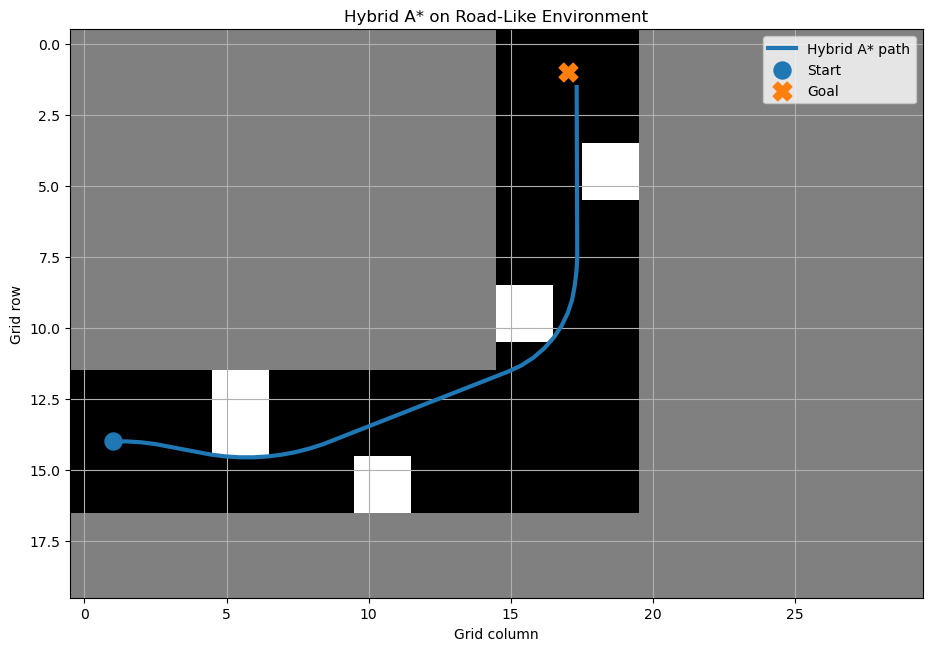

In [38]:
plt.figure(figsize=(11, 7.5))

# Draw environment
grid = np.zeros((planner.rows, planner.cols))

for r, c in offroad:
    grid[r, c] = 1

for r, c in planner.obstacles:
    if (r, c) not in offroad:
        grid[r, c] = 2

plt.imshow(
    grid,
    cmap="gray",
    vmin=0,
    vmax=2,
    origin="upper"
)

# Hybrid A* path
if hybrid_path:

    hy = [p[0] for p in hybrid_path]
    hx = [p[1] for p in hybrid_path]

    plt.plot(
        hx,
        hy,
        linewidth=3,
        label="Hybrid A* path"
    )

plt.scatter(
    start[1],
    start[0],
    s=150,
    label="Start"
)

plt.scatter(
    goal[1],
    goal[0],
    s=180,
    marker="X",
    label="Goal"
)

plt.xlabel("Grid column")
plt.ylabel("Grid row")
plt.title("Hybrid A* on Road-Like Environment")
plt.legend()
plt.grid()
plt.show()

## Part C — Planner Design Under Competing Constraints

Two collision-free paths can have different advantages. Path 1 is shorter but may require sharper steering and pass closer to obstacles, while Path 2 may be longer but smoother and have greater obstacle clearance.

To allow the planner to choose between them, a weighted cost function is implemented:

$$
J =
w_LJ_L+
w_\delta J_\delta+
w_CJ_C+
w_{\Delta\delta}J_{\Delta\delta}
$$

where the four terms represent path length, steering effort, obstacle clearance, and change in steering.

### 1. Path Length

The distance between every pair of consecutive path points is calculated and summed:

$$
J_L=\sum_i d_i
$$

This penalizes longer paths and encourages the planner to find an efficient route.

### 2. Steering Effort

The change in heading between consecutive path segments is calculated and converted into an approximate steering angle using the buggy's wheelbase.

The steering effort is then calculated as:

$$
J_\delta =
\sum_i
\left(
\frac{\delta_i}{\delta_{\max}}
\right)^2
$$

where $\delta_{\max}=32^\circ$.

The squared term gives a larger penalty to paths requiring large steering angles.

### 3. Obstacle Clearance

For every path point, the distance to the nearest obstacle is calculated. A reciprocal penalty is used:

$$
J_C =
\sum_i
\frac{1}{d_{\text{obs},i}+\epsilon}
$$

where $d_{\text{obs},i}$ is the distance to the nearest obstacle and $\epsilon$ prevents division by zero.

Therefore, a path passing close to obstacles receives a larger clearance cost.

### 4. Change in Steering

The change between consecutive steering angles is calculated:

$$
J_{\Delta\delta}
=
\sum_i
\left(
\frac{\delta_i-\delta_{i-1}}
{\delta_{\max}}
\right)^2
$$

This penalizes sudden changes in steering and encourages smoother vehicle motion.

### 5. Total Cost

The four components are combined using user-defined weights:

$$
J =
w_LJ_L+
w_\delta J_\delta+
w_CJ_C+
w_{\Delta\delta}J_{\Delta\delta}
$$

The planner calculates this total cost for both candidate paths. The path with the lower total cost is selected:

$$
\boxed{
P^*=\arg\min_P J(P)
}
$$

The weights used in the implementation are:

- $w_L$ — importance of path length
- $w_\delta$ — importance of steering effort
- $w_C$ — importance of obstacle clearance
- $w_{\Delta\delta}$ — importance of smooth steering changes

If the length weight is too high, the planner may select a short but aggressive path. If the steering-effort weight is too high, it may take unnecessarily long detours to avoid turning. If the clearance weight is too high, the planner may stay excessively far from obstacles. If the steering-change weight is too high, the planner may favour very gradual steering even when a sharper but safe manoeuvre would be more efficient.

The final section of the code visualises both candidate paths on the same road environment and reports their individual cost components and total costs. This makes it possible to see why the planner prefers one path over the other.

At lower speed (5 km/h), a shorter path can be given relatively greater importance because the vehicle has more time to respond to its surroundings. At the operating limit of 20 km/h, greater importance should be given to obstacle clearance, steering effort, and smooth steering changes. Thus, the preferred path can change with speed: a shorter path may be preferred at 5 km/h, while a smoother and higher-clearance path may be preferred at 20 km/h.

In [50]:
import numpy as np
import math


# ---------------------------------------------------------
# Cost function for competing paths
# ---------------------------------------------------------

def path_cost(path, obstacles,
              w_length=1.0,
              w_curvature=1.0,
              w_clearance=1.0,
              w_steering_change=1.0):

    if len(path) < 3:
        raise ValueError("Path must contain at least 3 points.")

    path = np.array(path, dtype=float)
    obstacles = np.array(list(obstacles), dtype=float)

    # -----------------------------------------------------
    # 1. Path length
    # -----------------------------------------------------

    segment_vectors = np.diff(path, axis=0)
    segment_lengths = np.linalg.norm(segment_vectors, axis=1)

    length_cost = np.sum(segment_lengths)


    # -----------------------------------------------------
    # 2. Estimate heading and steering
    # -----------------------------------------------------

    headings = np.arctan2(
        segment_vectors[:, 0],
        segment_vectors[:, 1]
    )

    # Change in heading between consecutive segments
    heading_changes = []

    for i in range(1, len(headings)):

        dtheta = (
            headings[i]
            - headings[i-1]
            + np.pi
        ) % (2 * np.pi) - np.pi

        heading_changes.append(dtheta)

    heading_changes = np.array(heading_changes)


    # Approximate steering angle from curvature
    # Using the buggy's wheelbase
    L = 2.30

    steering_angles = np.arctan(
        L * heading_changes
    )

    max_steer = math.radians(32)

    # -----------------------------------------------------
    # 3. Curvature / steering effort
    # -----------------------------------------------------

    curvature_cost = np.sum(
        (steering_angles / max_steer) ** 2
    )


    # -----------------------------------------------------
    # 4. Obstacle clearance
    # -----------------------------------------------------

    clearance_cost = 0.0

    for point in path:

        distances = np.linalg.norm(
            obstacles - point,
            axis=1
        )

        nearest_distance = np.min(distances)

        # Small epsilon prevents division by zero
        clearance_cost += 1.0 / (
            nearest_distance + 0.1
        )


    # -----------------------------------------------------
    # 5. Change in steering
    # -----------------------------------------------------

    if len(steering_angles) > 1:

        steering_changes = np.diff(
            steering_angles
        )

        steering_change_cost = np.sum(
            (steering_changes / max_steer) ** 2
        )

    else:
        steering_change_cost = 0.0


    # -----------------------------------------------------
    # Total weighted cost
    # -----------------------------------------------------

    total_cost = (
        w_length * length_cost
        + w_curvature * curvature_cost
        + w_clearance * clearance_cost
        + w_steering_change * steering_change_cost
    )

    return {
        "length": length_cost,
        "curvature": curvature_cost,
        "clearance": clearance_cost,
        "steering_change": steering_change_cost,
        "total": total_cost
    }

In [63]:
# Path 1:
# Shorter but makes sharper turns and passes closer to obstacles

path1 = [
    (14,1), (14,2), (14,3),
    (15,4), (15,5), (15,6), (15,7),
    (14,8), (13,9), (12,10),
    (12,11), (12,12), (12,13), (12,14), (12,15),
    (11,16), (11,17),
    (10,17), (9,17), (8,17), (7,17),
    (6,17), (5,17), (4,17), (3,17), (2,17), (1,17)
]
# Path 2:
# Hypothetical smoother path with greater clearance
path2 = [
    (14,1),
    (15,1), (15,2), (15,3), (15,4),
    (15,5), (15,6), (15,7), (15,8), (15,9),

    (14,9), (13,9), (12,9),
    (12,10), (12,11), (12,12), (12,13),
    (12,14), (12,15), (12,16), (12,17), (12,18),

    (11,18), (10,18), (9,18), (8,18),
    (7,18), (6,18),

    # Move away from the obstacle at rows 4-5, cols 18-19
    (6,17),
    (5,17), (4,17), (3,17), (2,17), (1,17)
]

In [64]:
obstacles = planner.obstacles

In [65]:
def check_collision_free(path, planner):

    for point in path:
        if not planner.is_free(point):
            return False, point

    return True, None


valid1, collision1 = check_collision_free(path1, planner)
valid2, collision2 = check_collision_free(path2, planner)

print("Path 1 collision-free:", valid1)

if not valid1:
    print("Path 1 collision at:", collision1)

print("Path 2 collision-free:", valid2)

if not valid2:
    print("Path 2 collision at:", collision2)

Path 1 collision-free: True
Path 2 collision-free: True


In [66]:
cost1 = path_cost(
    path1,
    obstacles,
    w_length=1.0,
    w_curvature=2.0,
    w_clearance=2.0,
    w_steering_change=1.5
)

cost2 = path_cost(
    path2,
    obstacles,
    w_length=1.0,
    w_curvature=2.0,
    w_clearance=2.0,
    w_steering_change=1.5
)

In [67]:
print("PATH 1")
print("-" * 30)

for key, value in cost1.items():
    print(f"{key:20s}: {value:.3f}")


print("\nPATH 2")
print("-" * 30)

for key, value in cost2.items():
    print(f"{key:20s}: {value:.3f}")


print("\nPREFERRED PATH:")

if cost1["total"] < cost2["total"]:
    print("Path 1")
else:
    print("Path 2")

PATH 1
------------------------------
length              : 28.071
curvature           : 27.250
clearance           : 18.784
steering_change     : 77.934
total               : 237.040

PATH 2
------------------------------
length              : 33.000
curvature           : 32.546
clearance           : 22.087
steering_change     : 70.516
total               : 248.040

PREFERRED PATH:
Path 1


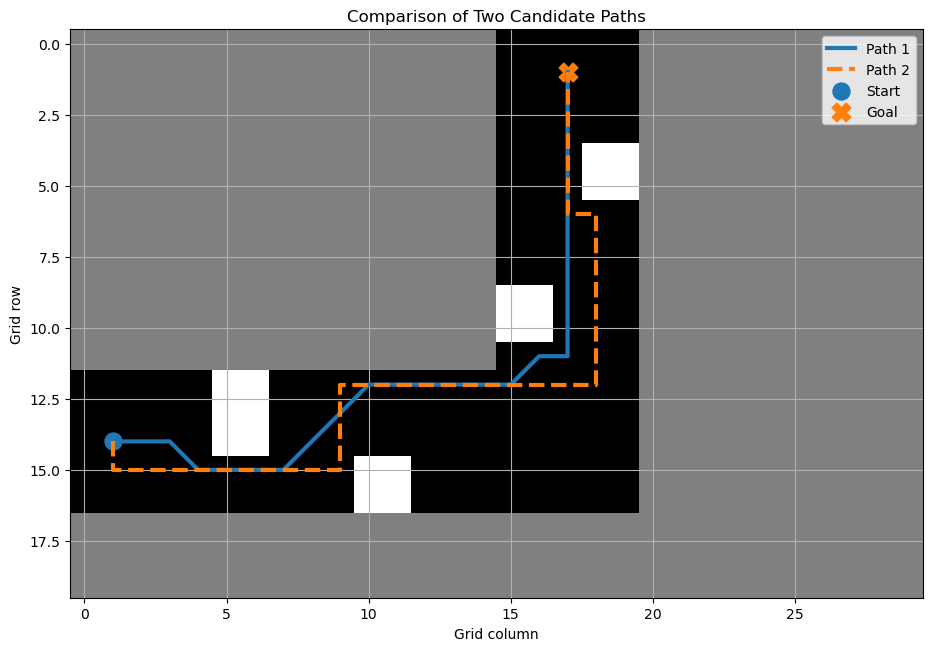

In [68]:
plt.figure(figsize=(11, 7.5))

grid = np.zeros((planner.rows, planner.cols))

for r, c in offroad:
    grid[r, c] = 1

for r, c in planner.obstacles:
    if (r, c) not in offroad:
        grid[r, c] = 2

plt.imshow(
    grid,
    cmap="gray",
    vmin=0,
    vmax=2,
    origin="upper"
)

# Path 1
p1 = np.array(path1)
plt.plot(
    p1[:, 1],
    p1[:, 0],
    linewidth=3,
    label="Path 1"
)

# Path 2
p2 = np.array(path2)
plt.plot(
    p2[:, 1],
    p2[:, 0],
    linewidth=3,
    linestyle="--",
    label="Path 2"
)

plt.scatter(
    start[1],
    start[0],
    s=150,
    label="Start"
)

plt.scatter(
    goal[1],
    goal[0],
    s=180,
    marker="X",
    label="Goal"
)

plt.xlabel("Grid column")
plt.ylabel("Grid row")
plt.title("Comparison of Two Candidate Paths")
plt.legend()
plt.grid()
plt.show()

In [69]:
# Lower speed: relatively more importance to distance
cost1_5 = path_cost(
    path1, obstacles,
    w_length=2.0,
    w_curvature=1.0,
    w_clearance=1.0,
    w_steering_change=0.5
)

cost2_5 = path_cost(
    path2, obstacles,
    w_length=2.0,
    w_curvature=1.0,
    w_clearance=1.0,
    w_steering_change=0.5
)


# Higher speed: stronger preference for smoothness and clearance
cost1_20 = path_cost(
    path1, obstacles,
    w_length=1.0,
    w_curvature=3.0,
    w_clearance=3.0,
    w_steering_change=2.0
)

cost2_20 = path_cost(
    path2, obstacles,
    w_length=1.0,
    w_curvature=3.0,
    w_clearance=3.0,
    w_steering_change=2.0
)


print("At 5 km/h:")
print("Path 1 cost:", cost1_5["total"])
print("Path 2 cost:", cost2_5["total"])

print("\nAt 20 km/h:")
print("Path 1 cost:", cost1_20["total"])
print("Path 2 cost:", cost2_20["total"])

At 5 km/h:
Path 1 cost: 141.14332960466925
Path 2 cost: 155.89083354272486

At 20 km/h:
Path 1 cost: 322.04162834679187
Path 2 cost: 337.93042629592236


## Effect of Cost Weights and Vehicle Speed

The planner combines path length, steering effort, obstacle clearance, and steering changes into a single cost. The weights determine which objective is prioritised.

### Effect of increasing individual weights

- **Path length weighted too heavily:**  
  The planner will strongly prefer the shortest route. It may choose Path 1 even if it has sharper turns and smaller obstacle clearance, making the path less suitable for the buggy.

- **Steering effort weighted too heavily:**  
  The planner will strongly avoid large steering angles and high curvature. This can result in unnecessarily long detours because the planner prioritises smooth turns over distance.

- **Obstacle clearance weighted too heavily:**  
  The planner will try to stay very far from obstacles. This improves safety margins but can make the route unnecessarily long and inefficient. In a narrow road, an excessive clearance penalty could even make a feasible route appear too costly.

- **Steering-change weighted too heavily:**  
  The planner will strongly avoid sudden changes in steering. This produces smoother motion but may cause the vehicle to take wider and longer routes than necessary.

Therefore, no single term should dominate the cost function. The weights should be balanced according to the vehicle's operating conditions.

### Effect of vehicle speed

At **5 km/h**, the buggy is travelling relatively slowly, so path efficiency can have greater importance. A shorter path such as **Path 1** may therefore be preferred, provided that its steering and clearance remain within acceptable limits.

At **20 km/h**, the buggy is operating at its speed cap. Smooth steering and sufficient obstacle clearance become more important because aggressive steering and small clearances leave less margin for tracking errors. The planner should therefore give relatively greater weight to steering effort, steering changes, and obstacle clearance, making the smoother **Path 2** more likely to be selected.

Thus, the preferred path can change with speed:

$$
5\text{ km/h}
\quad\rightarrow\quad
\text{greater relative preference for efficiency}
$$

$$
20\text{ km/h}
\quad\rightarrow\quad
\text{greater relative preference for smoothness and clearance}
$$

The exact preferred path depends on the numerical weights used in the cost function.